### Leaf segmenter

In [1]:
from ultralytics import YOLO

import cv2, numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline  

import os, glob
import numpy as np
from PIL import Image

SEG_DIR = 'output_segmented'

In [2]:
WEIGHTS = "yolo_segmenter_weights.pt"    # produced by train_yolo_seg.py
leaf_segmenter_model = YOLO(WEIGHTS)
print("loaded YOLO:", leaf_segmenter_model.task, "| classes:", leaf_segmenter_model.names)

loaded YOLO: segment | classes: {0: 'leaf'}


In [3]:
def segment_leaves(image, conf=0.25):
    """Full-size BGR images, one per leaf, background black. Largest leaf first."""
    res = leaf_segmenter_model.predict(image, conf=conf, retina_masks=True, verbose=False)[0]
    if res.masks is None:
        return []
    img = res.orig_img
    masks = res.masks.data.cpu().numpy().astype(np.uint8)
    masks = sorted(masks, key=lambda m: m.sum(), reverse=True)
    return [img * m[:, :, None] for m in masks]

In [4]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def list_images(folder):
    return sorted(os.path.join(folder, f) for f in os.listdir(folder)
                  if os.path.splitext(f)[1].lower() in IMG_EXTS)

FOLDERS = {'data/olive_leaves/train/Healthy': 0,
           'data/olive_leaves/train/aculus_olearius': 1,
           'data/olive_leaves/train/olive_peacock_spot': 2}

seg_info_rows = []
for folder, label in FOLDERS.items():
    for filename in list_images(folder):
        
        # Leaf segmentation
        bgr = cv2.imread(filename)
        leaves = segment_leaves(bgr)
        stem = os.path.splitext(os.path.basename(filename))[0]
        
        seg_info_rows.append({'path': filename,'folder': folder,'label': label,'n_leaves': len(leaves)})
        
        if leaves:
            for i, leaf in enumerate(leaves):
                rgb = cv2.cvtColor(leaf, cv2.COLOR_BGR2RGB)
                out = os.path.join(SEG_DIR, folder, f'{stem}_leaf{i:02d}.png')
                os.makedirs(os.path.dirname(out), exist_ok=True)
                Image.fromarray(rgb).save(out)
        else:
            im = Image.open(filename).convert('RGB')
            out = os.path.join(SEG_DIR, folder, f'{stem}_full.png')
            im.save(out)

In [5]:
# Save info of segmentation result
seg_result_df = pd.DataFrame(seg_info_rows)
seg_result_df.head()
seg_result_df[seg_result_df.n_leaves != 1]

,path,folder,label,n_leaves
9,data/olive_leaves/train/Healthy/A623.JPG,data/olive_leaves/train/Healthy,0,2
28,data/olive_leaves/train/Healthy/B-100.JPG,data/olive_leaves/train/Healthy,0,2
44,data/olive_leaves/train/Healthy/B-115.JPG,data/olive_leaves/train/Healthy,0,2
53,data/olive_leaves/train/Healthy/B-122.JPG,data/olive_leaves/train/Healthy,0,2
64,data/olive_leaves/train/Healthy/B-132 - Kopya.JPG,data/olive_leaves/train/Healthy,0,2
...,...,...,...,...
2692,data/olive_leaves/train/olive_peacock_spot/IMG...,data/olive_leaves/train/olive_peacock_spot,2,0
2695,data/olive_leaves/train/olive_peacock_spot/IMG...,data/olive_leaves/train/olive_peacock_spot,2,0
2703,data/olive_leaves/train/olive_peacock_spot/IMG...,data/olive_leaves/train/olive_peacock_spot,2,0
2705,data/olive_leaves/train/olive_peacock_spot/IMG...,data/olive_leaves/train/olive_peacock_spot,2,0


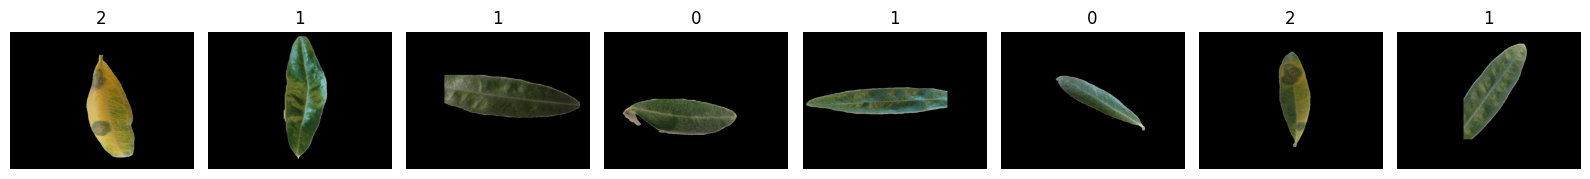

In [6]:
seg_files = [(p, label)
             for folder, label in FOLDERS.items()
             for p in list_images(os.path.join(SEG_DIR, folder))]

n = min(8, len(seg_files))
idx = np.random.choice(len(seg_files), n, replace=False)

fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
for ax, i in zip(np.atleast_1d(axes), idx):
    path, label = seg_files[i]
    ax.imshow(Image.open(path))
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()